In [ ]:
import os
import numpy as np
import librosa
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
from google.colab import drive
warnings.filterwarnings('ignore')

In [ ]:
# ========== CONFIGURATION ==========
SAMPLE_RATE = 52734  # From Table 1
DURATION = 3         # 3-second segments
TARGET_SAMPLES = SAMPLE_RATE * DURATION

# Log Mel parameters (from paper)
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
FMAX = SAMPLE_RATE  # 1-25.8 kHz from Table 1

# Only 3 classes as requested
CLASSES = {
    "SpeedBoat": 0,
    "UUV": 1,
    "KaiYuan": 2
}

# Training parameters
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.001

In [ ]:
# ========== CREATE DATASET ==========
class ShipAudioDataset(Dataset):
    """Dataset for 3-class ship audio classification with augmentation"""

    def __init__(self, features, labels, augment=False):
        self.features = features
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        feature = self.features[idx].copy()
        label = self.labels[idx]

        # Simple data augmentation
        if self.augment and np.random.random() > 0.5:
            # Time masking
            if feature.shape[1] > 10:  # Ensure enough time frames
                mask_width = np.random.randint(1, 5)
                mask_start = np.random.randint(0, feature.shape[1] - mask_width)
                feature[:, mask_start:mask_start + mask_width] = 0

            # Frequency masking
            if feature.shape[0] > 10:  # Ensure enough frequency bins
                mask_height = np.random.randint(1, 5)
                mask_start = np.random.randint(0, feature.shape[0] - mask_height)
                feature[mask_start:mask_start + mask_height, :] = 0

        # Add channel dimension
        feature = torch.FloatTensor(feature).unsqueeze(0)  # [1, 128, time]
        label = torch.tensor(label, dtype=torch.long)

        return feature, label

In [ ]:
class CRNN(nn.Module):
    """
    Convolutional Recurrent Neural Network for audio classification
    Improved with better feature extraction
    """

    def __init__(self, input_channels=1, num_classes=3, hidden_size=128):
        super(CRNN, self).__init__()

        # Enhanced CNN Feature Extractor (4 convolutional blocks with batch norm)
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=(2, 2))

        self.conv7 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn7 = nn.BatchNorm2d(256)
        self.conv8 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn8 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(kernel_size=(2, 2))

        self.dropout = nn.Dropout(0.5)

        # Calculate CNN output size dynamically
        self.cnn_output_size = self._calculate_cnn_output_size()

        # Bidirectional GRU for temporal modeling
        self.rnn = nn.GRU(
            input_size=self.cnn_output_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # Enhanced Classifier
        self.fc1 = nn.Linear(hidden_size * 2, 128)  # *2 for bidirectional
        self.bn9 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn10 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, num_classes)

    def _calculate_cnn_output_size(self):
        """Calculate CNN output feature size"""
        dummy_input = torch.zeros(1, 1, N_MELS, 311)  # Estimated time frames for 3s audio
        with torch.no_grad():
            x = self._cnn_forward(dummy_input, feature_only=True)
        return x.shape[1] * x.shape[2]  # channels * height

    def _cnn_forward(self, x, feature_only=False):
        """Forward pass through CNN layers"""
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)

        x = F.relu(self.bn7(self.conv7(x)))
        x = F.relu(self.bn8(self.conv8(x)))
        x = self.pool4(x)

        if feature_only:
            return x

        x = self.dropout(x)
        return x

    def forward(self, x):
        batch_size = x.size(0)

        # CNN forward
        x = self._cnn_forward(x)

        # Reshape for RNN: [batch, channels, height, time] -> [batch, time, channels*height]
        x = x.permute(0, 3, 1, 2)  # [batch, time, channels, height]
        x = x.reshape(batch_size, x.size(1), -1)  # [batch, time, features]

        # RNN forward
        rnn_out, _ = self.rnn(x)

        # Use mean pooling over time dimension (better than last time step)
        rnn_out = torch.mean(rnn_out, dim=1)

        # Classifier with batch norm
        x = F.relu(self.bn9(self.fc1(rnn_out)))
        x = self.dropout(x)
        x = F.relu(self.bn10(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

In [ ]:
class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance"""

    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [ ]:
def load_extracted_features(features_dir):
    """Load previously extracted features from disk"""
    print(f"Loading features from: {features_dir}")

    features = np.load(os.path.join(features_dir, "features.npy"), allow_pickle=True)
    labels = np.load(os.path.join(features_dir, "labels.npy"), allow_pickle=True)
    file_paths = np.load(os.path.join(features_dir, "file_paths.npy"), allow_pickle=True)
    metadata = np.load(os.path.join(features_dir, "metadata.npy"), allow_pickle=True).item()

    print(f"Loaded {len(features)} samples")
    print(f"Feature shape: {features[0].shape}")
    print(f"Class distribution: {metadata['class_distribution']}")

    return features, labels, file_paths, metadata

In [ ]:
# ========== LOAD AND PREPARE DATA ==========
print("=" * 60)
print("PREPARING DATA")
print("=" * 60)

# Load your features
FEATURES_DIR = "/content/drive/MyDrive/Ship_CRNN_3Class2/extracted_features_20251215_173741/"
features, labels, file_paths, metadata = load_extracted_features(FEATURES_DIR)

# Split data (70% train, 15% validation, 15% test)
X_train, X_temp, y_train, y_temp = train_test_split(
    features, labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"\nData Split:")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

# Calculate class distribution
train_class_counts = Counter(y_train)
print(f"\nTraining class distribution:")
for class_name, class_id in CLASSES.items():
    count = train_class_counts.get(class_id, 0)
    print(f"  {class_name}: {count} samples ({count/len(y_train)*100:.1f}%)")

PREPARING DATA
Loading features from: /content/drive/MyDrive/Ship_CRNN_3Class2/extracted_features_20251215_173741/
Loaded 8392 samples
Feature shape: (128, 309)
Class distribution: {'SpeedBoat': 5543, 'UUV': 902, 'KaiYuan': 1947}

Data Split:
Training samples: 5874
Validation samples: 1259
Test samples: 1259

Training class distribution:
  SpeedBoat: 3880 samples (66.1%)
  UUV: 631 samples (10.7%)
  KaiYuan: 1363 samples (23.2%)


In [ ]:
# ========== CALCULATE BALANCED CLASS WEIGHTS ==========
print("\n" + "=" * 60)
print("CALCULATING CLASS WEIGHTS")
print("=" * 60)

# Method 1: Inverse frequency (less aggressive than before)
class_counts = Counter(y_train)
total_samples = sum(class_counts.values())

# Option A: Inverse square root frequency (less aggressive)
class_weights = [1.0 / np.sqrt(count) for count in class_counts.values()]

# Option B: Inverse frequency normalized
# class_weights = [total_samples / (len(class_counts) * count) for count in class_counts.values()]
# class_weights = [w / sum(class_weights) * len(class_weights) for w in class_weights]  # Normalize

# Option C: Equal weights (test if weights are the problem)
# class_weights = [1.0, 1.0, 1.0]

print(f"Class weights: {class_weights}")
print(f"Original counts: {dict(class_counts)}")

# Convert to tensor
class_weights_tensor = torch.FloatTensor(class_weights)


CALCULATING CLASS WEIGHTS
Class weights: [np.float64(0.01605403247669839), np.float64(0.03980937143290165), np.float64(0.027086448924394324)]
Original counts: {np.int64(0): 3880, np.int64(1): 631, np.int64(2): 1363}


In [ ]:
# ========== CREATE DATALOADERS ==========
print("\n" + "=" * 60)
print("CREATING DATALOADERS")
print("=" * 60)

# Create datasets
train_dataset = ShipAudioDataset(X_train, y_train, augment=True)  # Augmentation for training
val_dataset = ShipAudioDataset(X_val, y_val, augment=False)
test_dataset = ShipAudioDataset(X_test, y_test, augment=False)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True  # Drop last incomplete batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


CREATING DATALOADERS
Train batches: 183
Val batches: 40
Test batches: 40


In [ ]:
# ========== INITIALIZE MODEL AND TRAINING ==========
print("\n" + "=" * 60)
print("INITIALIZING MODEL")
print("=" * 60)

# Initialize device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model
model = CRNN(num_classes=3, hidden_size=128)
model.to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Initialize loss function (try different options)
# Option 1: CrossEntropyLoss with balanced weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

# Option 2: Focal Loss (better for class imbalance)
# criterion = FocalLoss(alpha=class_weights_tensor.to(device), gamma=2.0)

# Option 3: Simple CrossEntropyLoss (to test if weights are the problem)
# criterion = nn.CrossEntropyLoss()

# Initialize optimizer with weight decay (L2 regularization)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,  # L2 regularization
    betas=(0.9, 0.999)
)

# Learning rate scheduler with patience
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=7,
    factor=0.5
)

# Early stopping
early_stopping_patience = 15
best_val_loss = float('inf')
patience_counter = 0


INITIALIZING MODEL
Using device: cuda
Total parameters: 3,184,483
Trainable parameters: 3,184,483


In [ ]:
# ========== TRAINING FUNCTIONS ==========
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(loader, desc="Training", leave=False)
    for batch_idx, (features, labels) in enumerate(progress_bar):
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        progress_bar.set_postfix({
            'loss': running_loss / (batch_idx + 1),
            'acc': f"{100 * correct / total:.1f}%"
        })

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels

def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Validation", leave=False)
        for features, labels in progress_bar:
            features, labels = features.to(device), labels.to(device)

            outputs = model(features)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            progress_bar.set_postfix({
                'loss': running_loss / (len(progress_bar) + 1),
                'acc': f"{100 * correct / total:.1f}%"
            })

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels

In [ ]:
# ========== TRAINING LOOP ==========
print("\n" + "=" * 60)
print("STARTING TRAINING")
print("=" * 60)

# Initialize history tracking
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'learning_rate': []
}

best_val_acc = 0.0
best_model_state = None

for epoch in range(EPOCHS):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print('='*50)

    # Train
    train_loss, train_acc, train_preds, train_labels = train_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # Validate
    val_loss, val_acc, val_preds, val_labels = validate_epoch(
        model, val_loader, criterion, device
    )

    # Update learning rate based on validation loss
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])

    # Calculate per-class accuracy for validation
    val_confusion = np.zeros((3, 3), dtype=int)
    for true, pred in zip(val_labels, val_preds):
        val_confusion[true, pred] += 1

    # Print epoch results
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} ({train_acc*100:.1f}%)")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} ({val_acc*100:.1f}%)")
    print(f"Learning Rate: {history['learning_rate'][-1]:.6f}")

    # Print per-class validation accuracy
    print("\nValidation Per-class Accuracy:")
    for i, class_name in enumerate(CLASSES.keys()):
        total = np.sum(val_confusion[i, :])
        correct = val_confusion[i, i]
        if total > 0:
            acc = correct / total
            print(f"  {class_name}: {acc:.4f} ({correct}/{total})")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        print(f"✓ Best model updated! (Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement for {patience_counter}/{early_stopping_patience} epochs")

    # Check for early stopping
    if patience_counter >= early_stopping_patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs!")
        break

    # Print confusion matrix every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"\nValidation Confusion Matrix (Epoch {epoch+1}):")
        print("Rows: True labels, Columns: Predicted labels")
        print(" " * 10 + "".join([f"{name[:8]:>8}" for name in CLASSES.keys()]))
        for i, true_name in enumerate(CLASSES.keys()):
            row = val_confusion[i]
            total = sum(row)
            percentages = [f"{count/total*100:.1f}%" if total > 0 else "0.0%" for count in row]
            print(f"{true_name[:8]:>8} " + " ".join([f"{p:>7}" for p in percentages]))

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\n✓ Restored best model (Val Acc: {best_val_acc:.4f})")


STARTING TRAINING

Epoch 1/30


Train Loss: 0.9257 | Train Acc: 0.6091 (60.9%)
Val Loss: 0.9258 | Val Acc: 0.6489 (64.9%)
Learning Rate: 0.001000

Validation Per-class Accuracy:
  SpeedBoat: 0.8869 (737/831)
  UUV: 0.3529 (48/136)
  KaiYuan: 0.1096 (32/292)
✓ Best model updated! (Val Loss: 0.9258, Val Acc: 0.6489)

Epoch 2/30


Train Loss: 0.7930 | Train Acc: 0.6699 (67.0%)
Val Loss: 0.9318 | Val Acc: 0.5290 (52.9%)
Learning Rate: 0.001000

Validation Per-class Accuracy:
  SpeedBoat: 0.5415 (450/831)
  UUV: 0.9926 (135/136)
  KaiYuan: 0.2774 (81/292)
  No improvement for 1/15 epochs

Epoch 3/30


Train Loss: 0.6905 | Train Acc: 0.6947 (69.5%)
Val Loss: 0.6953 | Val Acc: 0.6831 (68.3%)
Learning Rate: 0.001000

Validation Per-class Accuracy:
  SpeedBoat: 0.7677 (638/831)
  UUV: 0.8750 (119/136)
  KaiYuan: 0.3527 (103/292)
✓ Best model updated! (Val Loss: 0.6953, Val Acc: 0.6831)

Epoch 4/30


Train Loss: 0.6109 | Train Acc: 0.7380 (73.8%)
Val Loss: 0.5067 | Val Acc: 0.7641 (76.4%)
Learning Rate: 0.001000

Validation Per-class Accuracy:
  SpeedBoat: 0.7738 (643/831)
  UUV: 0.8456 (115/136)
  KaiYuan: 0.6986 (204/292)
✓ Best model updated! (Val Loss: 0.5067, Val Acc: 0.7641)

Epoch 5/30


...

Train Loss: 0.2574 | Train Acc: 0.8441 (84.4%)
Val Loss: 0.3076 | Val Acc: 0.8237 (82.4%)
Learning Rate: 0.000500

Validation Per-class Accuracy:
  SpeedBoat: 0.7617 (633/831)
  UUV: 1.0000 (136/136)
  KaiYuan: 0.9178 (268/292)
✓ Best model updated! (Val Loss: 0.3076, Val Acc: 0.8237)

Epoch 27/30


Train Loss: 0.2467 | Train Acc: 0.8523 (85.2%)
Val Loss: 0.3688 | Val Acc: 0.8276 (82.8%)
Learning Rate: 0.000500

Validation Per-class Accuracy:
  SpeedBoat: 0.7762 (645/831)
  UUV: 0.9926 (135/136)
  KaiYuan: 0.8973 (262/292)
  No improvement for 1/15 epochs

Epoch 28/30


Train Loss: 0.2569 | Train Acc: 0.8449 (84.5%)
Val Loss: 0.2877 | Val Acc: 0.8165 (81.7%)
Learning Rate: 0.000500

Validation Per-class Accuracy:
  SpeedBoat: 0.7341 (610/831)
  UUV: 0.9853 (134/136)
  KaiYuan: 0.9726 (284/292)
✓ Best model updated! (Val Loss: 0.2877, Val Acc: 0.8165)

Epoch 29/30


Train Loss: 0.2511 | Train Acc: 0.8487 (84.9%)
Val Loss: 0.3101 | Val Acc: 0.8245 (82.4%)
Learning Rate: 0.000500

Validation Per-class Accuracy:
  SpeedBoat: 0.7653 (636/831)
  UUV: 0.9853 (134/136)
  KaiYuan: 0.9178 (268/292)
  No improvement for 1/15 epochs

Epoch 30/30


Train Loss: 0.2501 | Train Acc: 0.8487 (84.9%)
Val Loss: 0.2797 | Val Acc: 0.8261 (82.6%)
Learning Rate: 0.000500

Validation Per-class Accuracy:
  SpeedBoat: 0.7485 (622/831)
  UUV: 1.0000 (136/136)
  KaiYuan: 0.9658 (282/292)
✓ Best model updated! (Val Loss: 0.2797, Val Acc: 0.8261)

Validation Confusion Matrix (Epoch 30):
Rows: True labels, Columns: Predicted labels
          SpeedBoa     UUV KaiYuan
SpeedBoa   74.8%    4.9%   20.2%
     UUV    0.0%  100.0%    0.0%
 KaiYuan    3.4%    0.0%   96.6%

✓ Restored best model (Val Acc: 0.8261)


In [ ]:
# ========== TESTING BEST MODEL ==========
print("\n" + "=" * 60)
print("TESTING FINAL MODEL")
print("=" * 60)

test_correct = 0
test_total = 0
class_correct = {class_id: 0 for class_id in CLASSES.values()}
class_total = {class_id: 0 for class_id in CLASSES.values()}
confusion_matrix = np.zeros((3, 3), dtype=int)
all_test_preds = []
all_test_labels = []

model.eval()
with torch.no_grad():
    for features, labels in tqdm(test_loader, desc="Testing"):
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        _, predicted = torch.max(outputs.data, 1)

        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

        # Update confusion matrix and per-class stats
        for i in range(len(labels)):
            true_label = labels[i].item()
            pred_label = predicted[i].item()
            class_total[true_label] += 1
            confusion_matrix[true_label, pred_label] += 1
            all_test_preds.append(pred_label)
            all_test_labels.append(true_label)

            if true_label == pred_label:
                class_correct[true_label] += 1

test_acc = test_correct / test_total

print(f"\nOverall Test Accuracy: {test_acc:.4f} ({test_correct}/{test_total})")
print(f"Test Accuracy (%): {test_acc * 100:.2f}%")

print("\nPer-class Accuracy:")
for class_name, class_id in CLASSES.items():
    if class_total[class_id] > 0:
        acc = class_correct[class_id] / class_total[class_id]
        print(f" {class_name}: {acc:.4f} ({class_correct[class_id]}/{class_total[class_id]})")

print("\nConfusion Matrix:")
print("Rows: True labels, Columns: Predicted labels")
print(" " * 10 + "".join([f"{name[:8]:>8}" for name in CLASSES.keys()]))
for i, true_name in enumerate(CLASSES.keys()):
    row = confusion_matrix[i]
    total = sum(row)
    percentages = [f"{count/total*100:.1f}%" if total > 0 else "0.0%" for count in row]
    print(f"{true_name[:8]:>8} " + " ".join([f"{p:>7}" for p in percentages]))


TESTING FINAL MODEL


Testing: 100%|██████████| 40/40 [00:01<00:00, 20.31it/s]


Overall Test Accuracy: 0.8181 (1030/1259)
Test Accuracy (%): 81.81%

Per-class Accuracy:
 SpeedBoat: 0.7380 (614/832)
 UUV: 0.9852 (133/135)
 KaiYuan: 0.9692 (283/292)

Confusion Matrix:
Rows: True labels, Columns: Predicted labels
          SpeedBoa     UUV KaiYuan
SpeedBoa   73.8%    6.6%   19.6%
     UUV    1.5%   98.5%    0.0%
 KaiYuan    3.1%    0.0%   96.9%



GENERATING VISUALIZATIONS


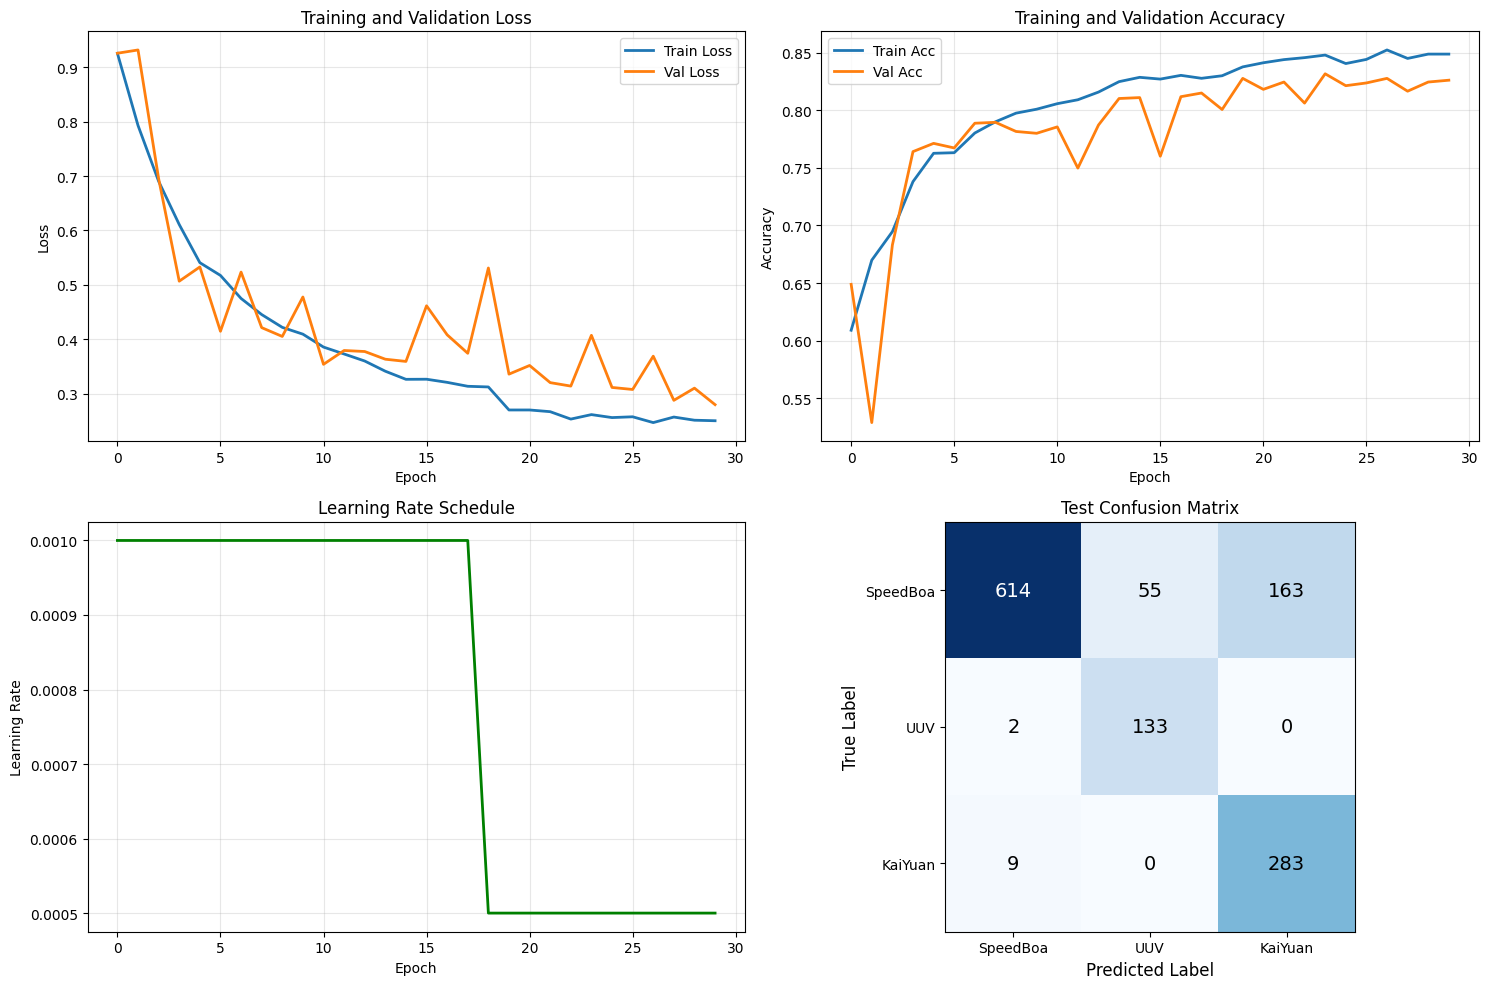

In [ ]:
# ========== VISUALIZATION ==========
print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss plot
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy plot
axes[0, 1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[0, 1].plot(history['val_acc'], label='Val Acc', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning rate plot
axes[1, 0].plot(history['learning_rate'], linewidth=2, color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].grid(True, alpha=0.3)

# Plot confusion matrix
axes[1, 1].imshow(confusion_matrix, cmap='Blues', interpolation='nearest')
for i in range(3):
    for j in range(3):
        text = axes[1, 1].text(j, i, confusion_matrix[i, j],
                           ha="center", va="center",
                           color="white" if confusion_matrix[i, j] > confusion_matrix.max()/2 else "black",
                           fontsize=14)
axes[1, 1].set_xticks(range(3))
axes[1, 1].set_yticks(range(3))
axes[1, 1].set_xticklabels([name[:8] for name in CLASSES.keys()])
axes[1, 1].set_yticklabels([name[:8] for name in CLASSES.keys()])
axes[1, 1].set_xlabel('Predicted Label', fontsize=12)
axes[1, 1].set_ylabel('True Label', fontsize=12)
axes[1, 1].set_title('Test Confusion Matrix', fontsize=12)

plt.tight_layout()
plt.show()


SAVING RESULTS
✓ Model saved to: /content/drive/MyDrive/Ship_CRNN_3Class2/trained_model_20251215_183052/ship_crnn_final.pth
✓ Training summary saved to: /content/drive/MyDrive/Ship_CRNN_3Class2/trained_model_20251215_183052
✓ Training complete!


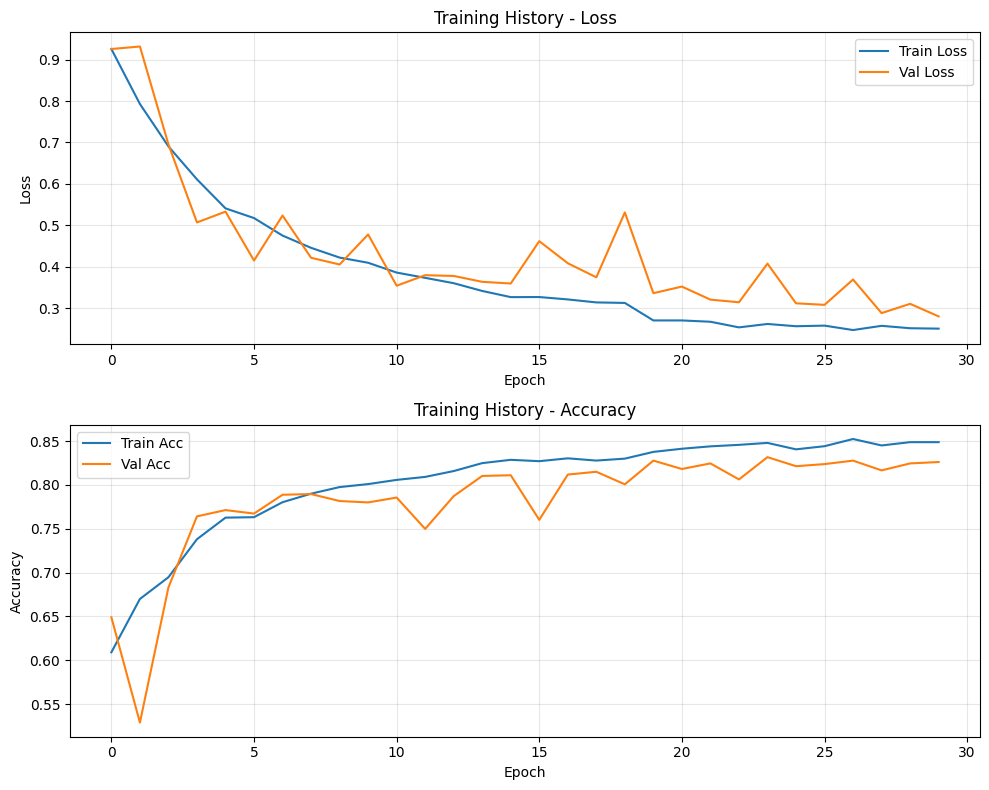

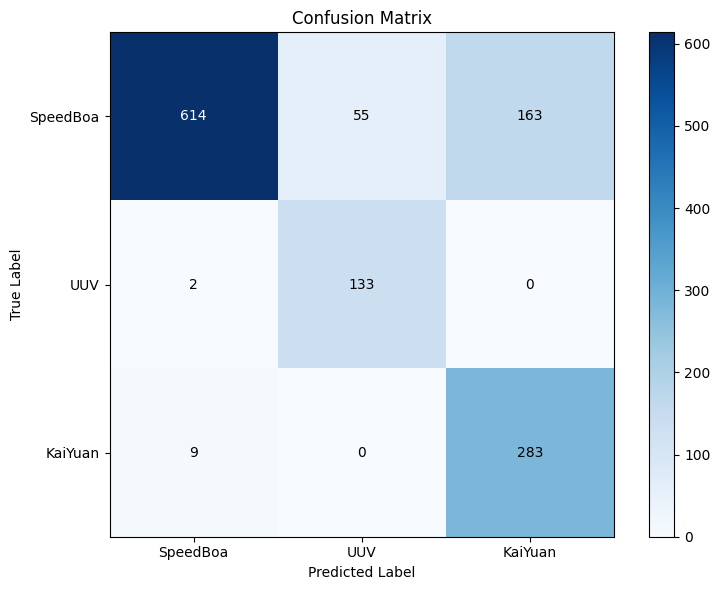

In [ ]:
# ========== SAVE RESULTS ==========
print("\n" + "=" * 60)
print("SAVING RESULTS")
print("=" * 60)

# Create output directory
import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
SAVE_DIR = "/content/drive/MyDrive/Ship_CRNN_3Class2/trained_model_" + timestamp
os.makedirs(SAVE_DIR, exist_ok=True)

# Save final model
model_path = os.path.join(SAVE_DIR, "ship_crnn_final.pth")
torch.save({
    'epoch': len(history['train_loss']),
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'per_class_acc': {class_name: class_correct[CLASSES[class_name]]/class_total[CLASSES[class_name]]
                      for class_name in CLASSES.keys() if class_total[CLASSES[class_name]] > 0},
    'confusion_matrix': confusion_matrix,
    'class_weights': class_weights,
    'classes': CLASSES,
    'history': history,
    'config': {
        'sample_rate': SAMPLE_RATE,
        'duration': DURATION,
        'n_mels': N_MELS,
        'n_fft': N_FFT,
        'hop_length': HOP_LENGTH,
        'fmax': FMAX,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'epochs': EPOCHS
    }
}, model_path)

# Save training curves
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History - Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training History - Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_history.png"), dpi=150, bbox_inches='tight')

# Save confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix, cmap='Blues')
for i in range(3):
    for j in range(3):
        plt.text(j, i, confusion_matrix[i, j],
                 ha="center", va="center",
                 color="white" if confusion_matrix[i, j] > confusion_matrix.max()/2 else "black")
plt.xticks(range(3), [name[:8] for name in CLASSES.keys()])
plt.yticks(range(3), [name[:8] for name in CLASSES.keys()])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=150, bbox_inches='tight')

# Save summary report
with open(os.path.join(SAVE_DIR, "training_summary.txt"), "w") as f:
    f.write("=" * 60 + "\n")
    f.write("MODEL TRAINING SUMMARY\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Training completed: {timestamp}\n")
    f.write(f"Total epochs trained: {len(history['train_loss'])}\n")
    f.write(f"Best validation accuracy: {best_val_acc:.4f}\n")
    f.write(f"Test accuracy: {test_acc:.4f}\n\n")
    f.write("Class distribution in training:\n")
    for class_name, count in train_class_counts.items():
        f.write(f"  {class_name}: {count} samples\n")
    f.write(f"\nClass weights used: {class_weights}\n")
    f.write(f"\nPer-class test accuracy:\n")
    for class_name, class_id in CLASSES.items():
        if class_total[class_id] > 0:
            acc = class_correct[class_id] / class_total[class_id]
            f.write(f"  {class_name}: {acc:.4f} ({class_correct[class_id]}/{class_total[class_id]})\n")

print(f"✓ Model saved to: {model_path}")
print(f"✓ Training summary saved to: {SAVE_DIR}")
print(f"✓ Training complete!")